In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

sns.set_style("whitegrid")

import matplotlib

# set font size to 16
matplotlib.rcParams.update({"font.size": 16})

SEED = 4

In [2]:
#Use the csv files again
#Load accuracy, precision, recall and f1 score
def load_dict_from_csv(filename):
    df = pd.read_csv(filename)
    nested_dict = {}
    for (run, method), group in df.groupby(['Run', 'Method']):
        nested_dict.setdefault(run, {})[method] = group['Value'].tolist()
    return nested_dict

def get_summary(loaded_dict):
    methods = list(loaded_dict[0].keys())
    summary_dict = {}
    for method in methods:
        all_runs = np.array([loaded_dict[run][method] for run in range(n_runs)]) # shape: (100, array_length)
        # Compute statistics
        mean_values = np.mean(all_runs, axis=0)
        plow_values = np.percentile(all_runs, 10, axis=0)
        phigh_values = np.percentile(all_runs, 90, axis=0)
        # Store in nested structure for easy plotting
        summary_dict[method] = {
            "mean": mean_values.tolist(),
            "plow": plow_values.tolist(),
            "phigh": phigh_values.tolist()
        }
    return summary_dict

#Load type distributions
def load_distributions_dict_from_csv(filename, all_labels):
    df = pd.read_csv(filename)
    dist_dict = {}
    for (run, method), group in df.groupby(['Run', 'Method']):
        arrs = group[all_labels].values.tolist()
        dist_dict.setdefault(run, {})[method] = arrs
    return dist_dict

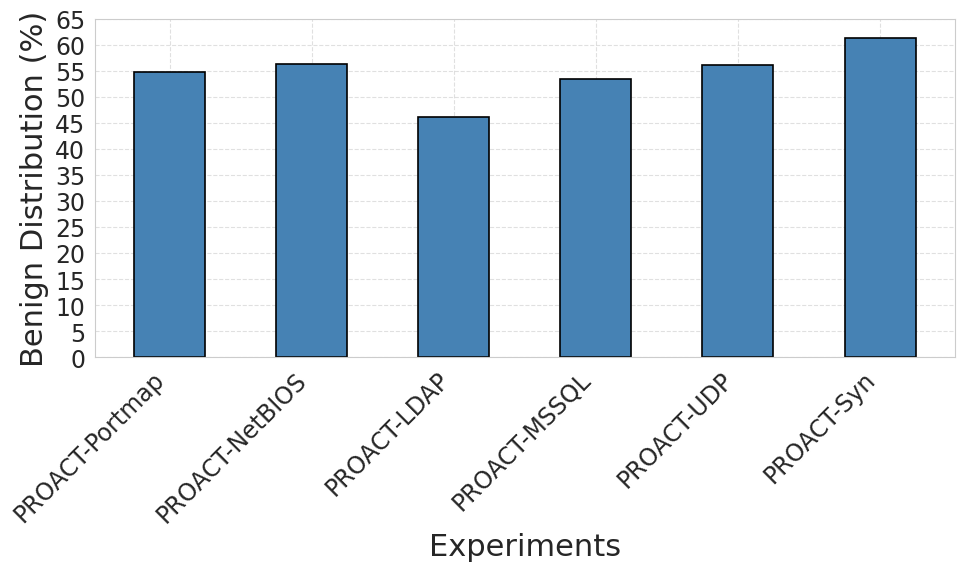

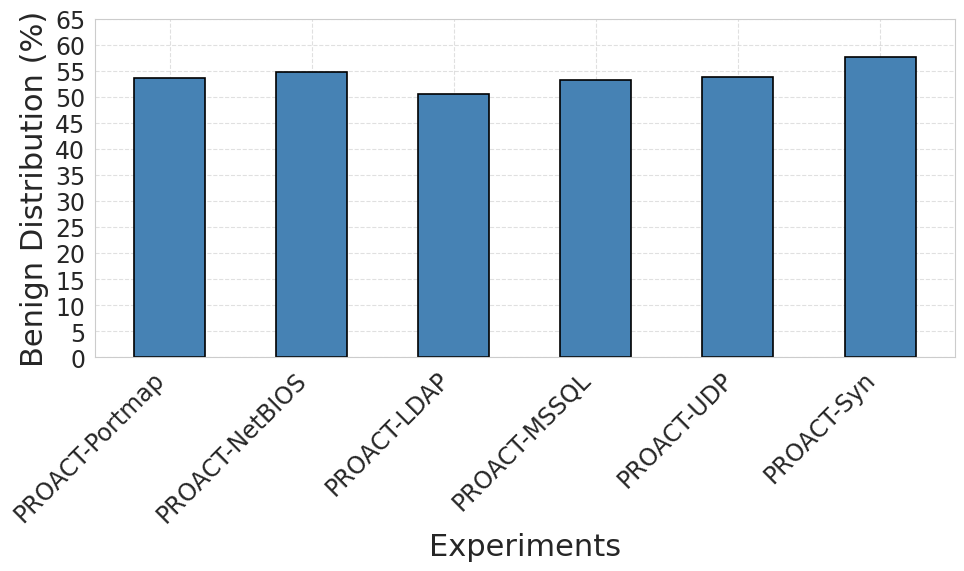

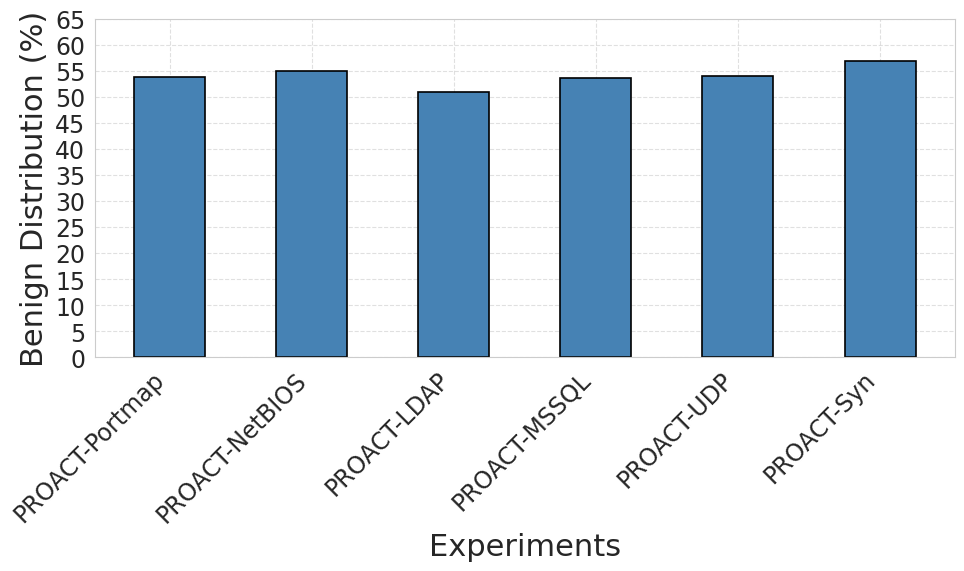

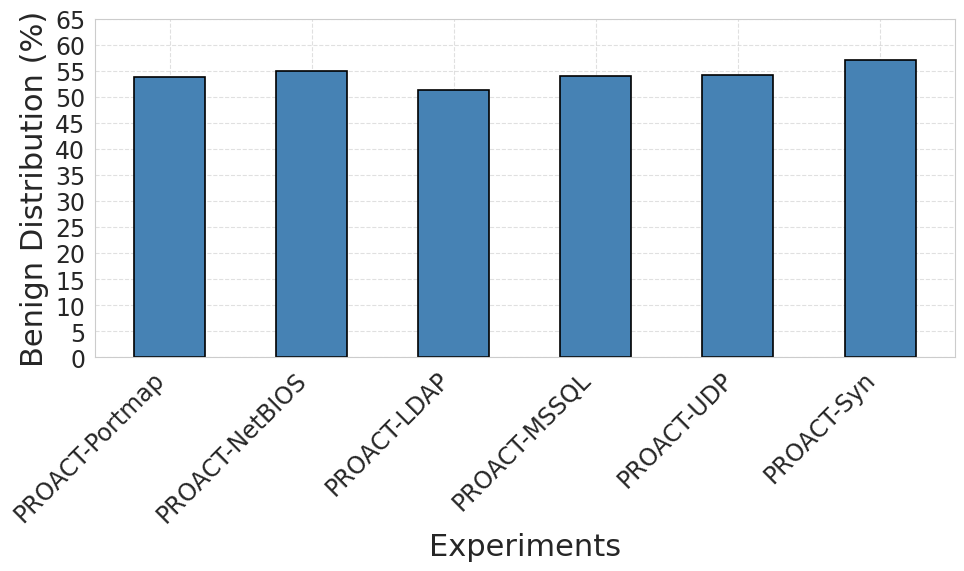

In [3]:
n_runs = 100
# Define all start types to compare
all_start_types = ["Portmap", "NetBIOS", "LDAP", "MSSQL", "UDP", "Syn"]

# Store BENIGN distributions for each start_type
benign_distributions = {}  # {start_type: {datasize_idx: benign_value}}

# Load data for each start_type
for st in all_start_types:
    benign_distributions[st] = {}
    
    # Load the results for this start_type
    f1score_dict_st = load_dict_from_csv(f"./results_dictionaries/f1score_dict_{st}_{n_runs}.csv")
    f1score_summary_st = get_summary(f1score_dict_st)
    
    # Get the mean sorting for this start_type
    f1score_summary_mean_st = defaultdict(lambda: None)
    for method in f1score_summary_st.keys():
        if len(f1score_summary_st[method]["mean"]) == 351:
            f1score_summary_mean_st[method] = np.array(f1score_summary_st[method]["mean"])[::10]
            f1score_summary_mean_st[method] = np.array(f1score_summary_mean_st[method])[1:]
        else:
            f1score_summary_mean_st[method] = np.array(f1score_summary_st[method]["mean"])[1:]

    methods_st = list(f1score_summary_mean_st.keys())
    
    # Find thresholds for this start_type
    f1_events_st = []
    for method in methods_st:
        values = np.array(f1score_summary_mean_st[method])
        for i, v in enumerate(values):
            f1_events_st.append((method, i, v))
    
    f1_events_st.sort(key=lambda x: x[1])
    
    first_95_st = None
    first_99_st = None
    second_99_st = None
    third_99_st = None
    seen_99_methods_st = set()
    
    for method, idx, val in f1_events_st:
        if first_95_st is None and val >= 0.95:
            first_95_st = (method, idx)
        if val >= 0.99 and method not in seen_99_methods_st:
            seen_99_methods_st.add(method)
            if first_99_st is None:
                first_99_st = (method, idx)
            elif second_99_st is None:
                second_99_st = (method, idx)
            elif third_99_st is None:
                third_99_st = (method, idx)
        if first_95_st and first_99_st and second_99_st and third_99_st:
            break
    
    datasize_st = [first_95_st[1] if first_95_st else 0, 
                   first_99_st[1] if first_99_st else 0, 
                   second_99_st[1] if second_99_st else 0, 
                   third_99_st[1] if third_99_st else 0]
    
    # Load distributions for this start_type
    all_distr_len_st = defaultdict(lambda: defaultdict(list))
    mean_distr_len_st = defaultdict(lambda: defaultdict(list))
    
    all_labels = ["BENIGN", "Portmap", "NetBIOS", "LDAP", "MSSQL", "UDP", "UDPLag", "Syn"]
    distributions_dict_st = load_distributions_dict_from_csv(f"./results_dictionaries/distributions_dict_{st}_{n_runs}.csv", all_labels)
    
    idx_batch = list(range(0, 35))
    idx_single = [i*10 + 9 for i in idx_batch]
    
    for run in range(n_runs):
        for method in methods_st:
            distr_arr = np.array(distributions_dict_st[run][method])
            for k in datasize_st:
                if len(distr_arr) == 350:
                    all_distr_len_st[k][method].append(distr_arr[idx_single[k]])
                else:
                    all_distr_len_st[k][method].append(distr_arr[idx_batch[k]])
    
    # Mean Distributions
    for siz in datasize_st:
        for method in methods_st:
            mean_distr_len_st[siz][method] = np.mean(all_distr_len_st[siz][method], axis=0)
    
    # Extract BENIGN (index 0) for each datasize threshold
    for i, siz in enumerate(datasize_st):
        benign_val = 0
        count = 0
        for method in methods_st:
            benign_val += mean_distr_len_st[siz][method][0]  # Index 0 is BENIGN
            count += 1
        benign_distributions[st][i] = benign_val / count if count > 0 else 0

# Plot 4 bar graphs, one for each datasize threshold
benchmark_names = ["95% F1 Score", "1st Strategy 99%", "2nd Strategy 99%", "3rd Strategy 99%"]

for datasize_idx in range(4):
    plt.figure(figsize=(10, 6))
    
    start_types_names = [f"PROACT-{st}" for st in all_start_types]
    benign_values = [benign_distributions[st][datasize_idx] for st in all_start_types]
    
    x = np.arange(len(start_types_names))
    plt.bar(x, benign_values, color='steelblue', edgecolor='black', linewidth=1.2, width=0.5)
    
    plt.xlabel("Experiments", fontsize=22)
    plt.ylabel("Benign Distribution (%)", fontsize=22)
    #plt.title(f"BENIGN Distribution at {benchmark_names[datasize_idx]}", fontsize=14)
    plt.xticks(x, start_types_names, rotation=45, ha='right', fontsize=17)
    plt.yticks(np.arange(0, 76, 5), fontsize=17)
    plt.ylim(0, 65)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(f"./Benign_distributions/benign_distribution_BM{datasize_idx+1}.pdf", bbox_inches='tight')
    plt.show()